## More tips of eda

In [1]:
# import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.isnull().sum() / len(df) * 100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [6]:
# drop the deck column
df.drop('deck', axis=1, inplace=True)

In [8]:
df['age'].mean()

np.float64(29.69911764705882)

In [9]:
df['age'].median()

np.float64(28.0)

In [11]:
df['age'].mode()[0]

np.float64(24.0)

In [25]:
# filling missing values with mean for numerical columns
df['age'] = df['age'].fillna(df['age'].mean())
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [26]:
df.isnull().sum() 

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

<Axes: >

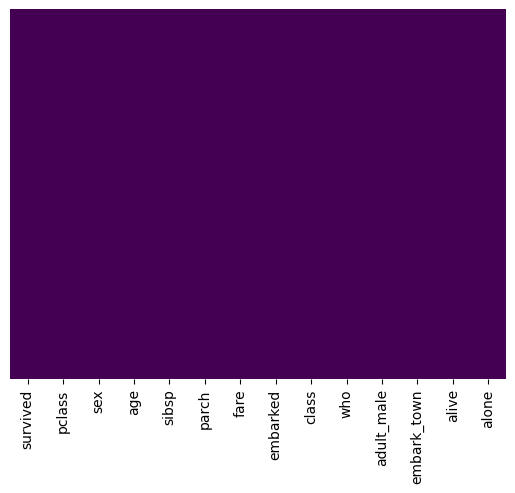

In [27]:
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')

## Binning

In [28]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


<Axes: xlabel='age', ylabel='Count'>

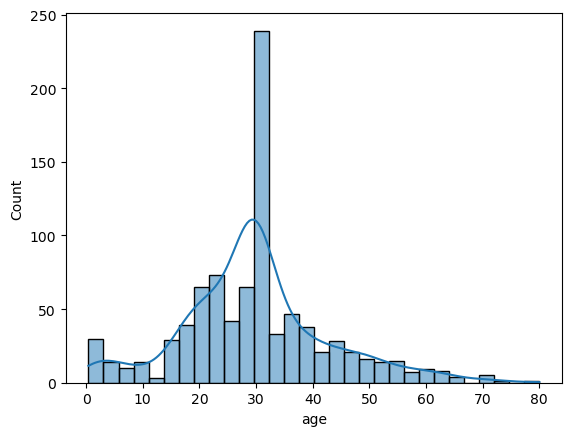

In [30]:
sns.histplot(df['age'], bins=30, kde=True)

In [31]:
bins = [0, 18, 35, 60, 100]
labels = ['Child', 'Young Adult', 'Adult', 'Senior']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

In [34]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,age_group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,Young Adult
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,Adult
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,Young Adult
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Young Adult
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,Young Adult


In [35]:
df['age_group'].value_counts()

age_group
Young Adult    535
Adult          195
Child          139
Senior          22
Name: count, dtype: int64

## Data Filtration

In [36]:
df.columns  

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone', 'age_group'],
      dtype='str')

In [37]:
data = df[['fare', 'age',  'class', 'parch']]

In [38]:
data.head()

,fare,age,class,parch
0,7.2500,22.0,Third,0
1,71.2833,38.0,First,0
2,7.9250,26.0,Third,0
3,53.1000,35.0,First,0
4,8.0500,35.0,Third,0


In [40]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   fare    891 non-null    float64 
 1   age     891 non-null    float64 
 2   class   891 non-null    category
 3   parch   891 non-null    int64   
dtypes: category(1), float64(2), int64(1)
memory usage: 22.0 KB


In [42]:
data['class'].value_counts()

class
Third     491
First     216
Second    184
Name: count, dtype: int64

In [43]:
data_first_class = data[data['class'] == 'First']
data_first_class.head()

,fare,age,class,parch
1,71.2833,38.0,First,0
3,53.1000,35.0,First,0
6,51.8625,54.0,First,0
11,26.5500,58.0,First,0
23,35.5000,28.0,First,0


In [45]:
df['fare'].min()

np.float64(0.0)

In [47]:
df['fare'].max()

np.float64(512.3292)

In [48]:
# how to add two filter
data[(data['class'] == 'First') & (data['age'] > 30)]

,fare,age,class,parch
1,71.2833,38.0,First,0
3,53.1000,35.0,First,0
6,51.8625,54.0,First,0
11,26.5500,58.0,First,0
30,27.7208,40.0,First,0
...,...,...,...,...
862,25.9292,48.0,First,0
867,50.4958,31.0,First,0
871,52.5542,47.0,First,1
872,5.0000,33.0,First,0
